# 04 — A/B Test Evaluation
Experiment design · Statistical testing · Business recommendation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100

## Power analysis

In [2]:
def required_n(baseline, mde, alpha=0.05, power=0.80):
    za = stats.norm.ppf(1-alpha/2)
    zb = stats.norm.ppf(power)
    p1, p2 = baseline, baseline+mde
    pb = (p1+p2)/2
    return int(np.ceil((za*np.sqrt(2*pb*(1-pb)) + zb*np.sqrt(p1*(1-p1)+p2*(1-p2)))**2 / mde**2))

baseline = 0.74
print(f'Baseline conversion: {baseline:.0%}')
print(f'{"MDE":>6}  {"n/group (80%)": >14}  {"Total":>10}')
for mde in [0.02, 0.03, 0.05, 0.08]:
    n = required_n(baseline, mde)
    print(f'{mde:>6.0%}  {n:>14,}  {n*2:>10,}')

Baseline conversion: 74%
   MDE   n/group (80%)       Total
    2%           7,358      14,716
    3%           3,226       6,452
    5%           1,128       2,256
    8%             420         840


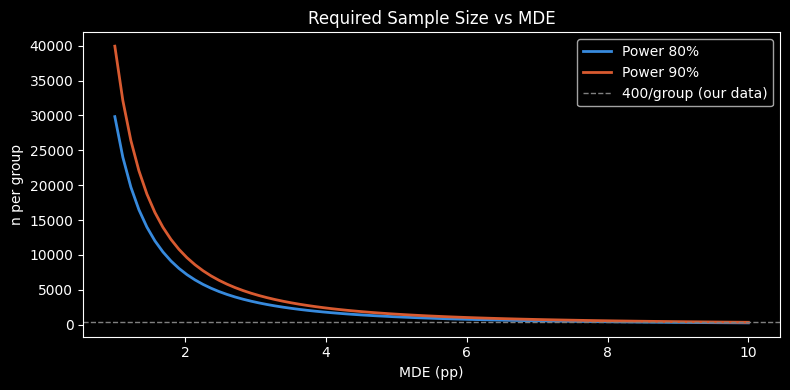

In [3]:
mdes = np.linspace(0.01, 0.10, 80)
plt.figure(figsize=(8, 4))
plt.plot(mdes*100, [required_n(baseline, m, power=0.80) for m in mdes],
         lw=2, color='#378ADD', label='Power 80%')
plt.plot(mdes*100, [required_n(baseline, m, power=0.90) for m in mdes],
         lw=2, color='#D85A30', label='Power 90%')
plt.axhline(400, color='gray', ls='--', lw=1, label='400/group (our data)')
plt.title('Required Sample Size vs MDE')
plt.xlabel('MDE (pp)'); plt.ylabel('n per group')
plt.legend(); plt.tight_layout(); plt.show()

## Simulate A/B test

In [4]:
df = pd.read_csv('sample_rides.csv', parse_dates=['timestamp'])
np.random.seed(42)
n = 400

ctrl = df.sample(n, random_state=1).copy()
ctrl['group'] = 'control'
trt  = df.sample(n, random_state=2).copy()
trt['group']  = 'treatment'

# Treatment: -10% price
trt['final_price_eur'] = trt['final_price_eur'] * 0.90
trt['conversion'] = np.random.binomial(
    1, np.clip(trt['conversion']*1.03 + 0.04, 0.05, 0.99), n)

exp = pd.concat([ctrl, trt], ignore_index=True)
print(exp.groupby('group')[['final_price_eur','conversion']].mean().round(4))

           final_price_eur  conversion
group                                 
control             8.0766      0.7450
treatment           7.3824      0.7325


## Statistical test

In [5]:
ctrl_c = ctrl['conversion'].values
trt_c  = trt['conversion'].values

ctrl_m, trt_m = ctrl_c.mean(), trt_c.mean()
diff = trt_m - ctrl_m
t_stat, p_val = stats.ttest_ind(trt_c, ctrl_c, equal_var=False)
se = np.sqrt(ctrl_c.var()/n + trt_c.var()/n)
ci_lo, ci_hi = diff - 1.96*se, diff + 1.96*se

print(f'Control:       {ctrl_m:.4f}')
print(f'Treatment:     {trt_m:.4f}')
print(f'Absolute lift: {diff:+.4f} ({diff*100:+.2f} pp)')
print(f'Relative lift: {diff/ctrl_m*100:+.2f}%')
print(f'95% CI:        [{ci_lo:.4f}, {ci_hi:.4f}]')
print(f'p-value:       {p_val:.4f}')
print(f'Significant:   {"YES" if p_val<0.05 else "NO"}  (alpha=0.05)')

Control:       0.7450
Treatment:     0.7325
Absolute lift: -0.0125 (-1.25 pp)
Relative lift: -1.68%
95% CI:        [-0.0734, 0.0484]
p-value:       0.6878
Significant:   NO  (alpha=0.05)


## Visualise

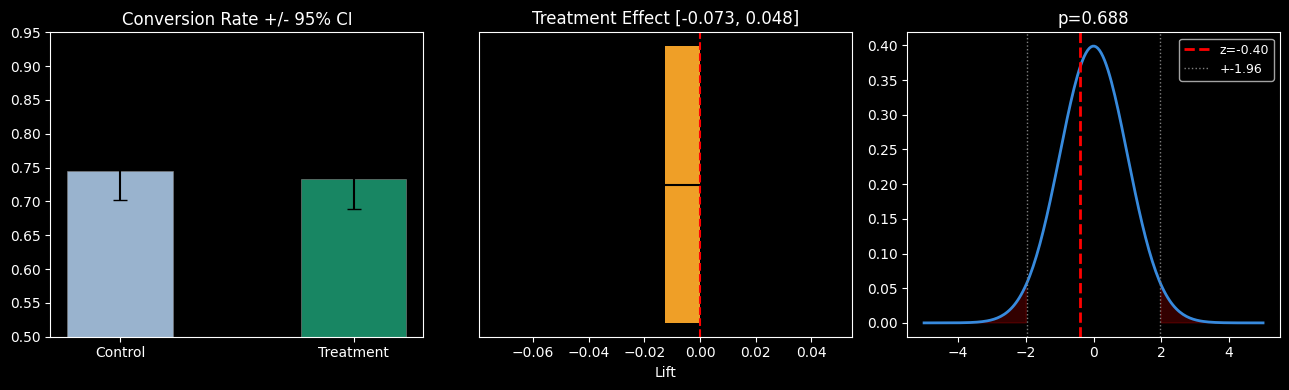

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for i, (label, val, arr) in enumerate(zip(
        ['Control','Treatment'],[ctrl_m,trt_m],[ctrl_c,trt_c])):
    ci = 1.96*np.sqrt(val*(1-val)/n)
    axes[0].bar(i, val, 0.45, color=['#B5D4F4','#1D9E75'][i], alpha=0.85, edgecolor='gray', lw=0.5)
    axes[0].errorbar(i, val, ci, fmt='none', color='black', capsize=5)
axes[0].set_xticks([0,1]); axes[0].set_xticklabels(['Control','Treatment'])
axes[0].set(title='Conversion Rate +/- 95% CI', ylim=(0.5, 0.95))

axes[1].barh([0], [diff], xerr=[[diff-ci_lo],[ci_hi-diff]],
             color='#EF9F27', capsize=6, height=0.25)
axes[1].axvline(0, color='red', ls='--', lw=1.5)
axes[1].set(title=f'Treatment Effect [{ci_lo:.3f}, {ci_hi:.3f}]', yticks=[], xlabel='Lift')

zs = np.linspace(-5, 5, 200)
axes[2].plot(zs, stats.norm.pdf(zs), color='#378ADD', lw=2)
axes[2].axvline(t_stat, color='red', ls='--', lw=2, label=f'z={t_stat:.2f}')
axes[2].axvline( 1.96,  color='gray', ls=':', lw=1, label='+-1.96')
axes[2].axvline(-1.96,  color='gray', ls=':', lw=1)
axes[2].fill_between(zs, stats.norm.pdf(zs),
    where=(zs>1.96)|(zs<-1.96), alpha=0.2, color='red')
axes[2].set(title=f'p={p_val:.3f}'); axes[2].legend(fontsize=9)
plt.tight_layout(); plt.show()

## Business recommendation

In [7]:
ctrl_rev  = ctrl['final_price_eur'].mean() * ctrl_m
trt_rev   = trt['final_price_eur'].mean()  * trt_m
delta_rev = trt_rev - ctrl_rev

print('Business Impact')
print('='*38)
print(f'Revenue/ride control  : EUR {ctrl_rev:.3f}')
print(f'Revenue/ride treatment: EUR {trt_rev:.3f}')
print(f'Delta per ride        : EUR {delta_rev:+.3f}')
if delta_rev > 0 and p_val < 0.05:
    print('\nRECOMMENDATION: ROLL OUT')
    print(f'  Net revenue improves by EUR {delta_rev:.3f}/ride')
elif p_val >= 0.05:
    print('\nRECOMMENDATION: DO NOT ROLL OUT')
    print('  Effect not statistically significant')
else:
    print('\nRECOMMENDATION: DO NOT ROLL OUT')
    print('  Conversion up but revenue per ride falls')

Business Impact
Revenue/ride control  : EUR 6.017
Revenue/ride treatment: EUR 5.408
Delta per ride        : EUR -0.609

RECOMMENDATION: DO NOT ROLL OUT
  Effect not statistically significant
